# Primary sample selection and RV matching

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 2000000
from matplotlib.pyplot import figure
from astropy.io import fits
from pathlib import Path

## Primary sample selection
In this notebook, we are selecting primary sample with targets similar to Gaia NS1: metal-poor main sequence stars with surface temperature 4000~7000 K. 

In [2]:
df = pd.read_csv("Data/dr9_v2.0_MRS_stellar.csv")

In [3]:
#condition 1: [Fe/H]<-1
#condition 2: logg_lasp > 4.0
#condition 3: 4000 <teff_lasp <7000
df_target = df.loc[(df["feh_lasp"] < -1.0) & (df["feh_lasp"]!= -9999) & (df["teff_lasp"] != -9999) & (df["logg_lasp"] > 4.0) & (df["teff_lasp"]<7000) & (df["teff_lasp"]>4000) & (df["snr"] > 10)]

In [4]:
df = df.drop_duplicates(subset = ["designation"])
len(df)

895377

In [5]:
df_target = df_target.drop_duplicates(subset = ["designation"])
len(df_target)

4441

(3000.0, 8700.0)

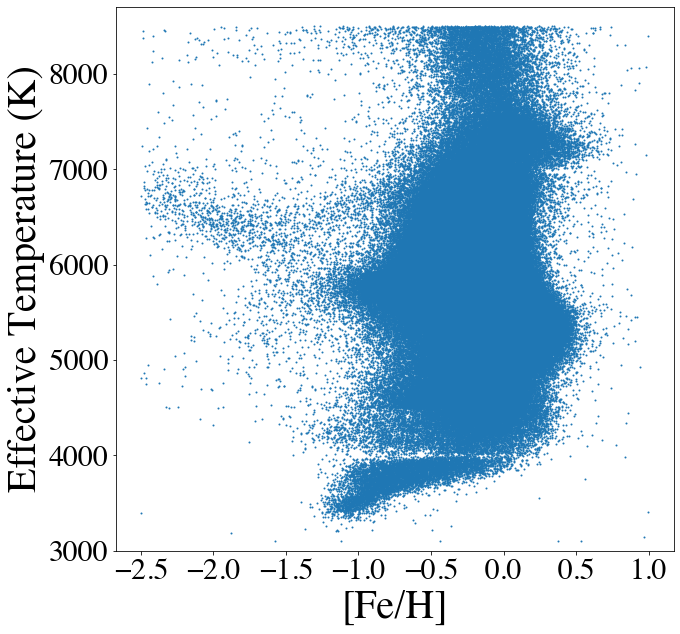

In [6]:
#plot the distribution of main sequence stars according to temperature and metallicity
plt.rcParams.update({'font.family':'times'})
fig= figure(figsize=(10,10))

df_plot = df.loc[(df["feh_lasp"]!= -9999) & (df["teff_lasp"] != -9999) & (df["logg_lasp"] >4.0)]
x = np.array(df_plot['feh_lasp'])
y = np.array(df_plot['teff_lasp'])
plt.scatter(x, y, s = 1)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('[Fe/H]', fontsize = 40)
plt.ylabel('Effective Temperature (K)', fontsize = 40)
plt.ylim(3000, 8700)

In [7]:
#construct a txt file for objects search in LAMOST MRS
desig_list = df_target['designation'].tolist()
desig_list = list_without_headings = [item.replace('LAMOST ', "", 1) for item in desig_list]
file1 = open('Data/MRS_Sample_to_search', 'w')
for item in desig_list:
        file1.write(f"{item}\n")
file1.close()

df_sample = df_target[df_target['designation'].isin(desig_list)]